<h1 style="font size=36px">1. Setup and Data Loading</h1>

In [9]:
#Necessary Libraries
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
print(f'shap version : {shap.__version__}')

shap version : 0.51.0


In [10]:
#Load Data
data=pd.read_csv(r'C:\Users\ADMIN\OneDrive\Desktop\Customer Churn Prediction\Data\Processed\cleaned_customer_churn_data.csv')

<h1 style="font size=36px">2.Data Preparation</h1>

In [11]:
#Separating the features from the target variable
X=data.drop('Churn',axis=1)
Y=data['Churn'].map({'Yes':1,'No':0})

In [12]:
#Train test split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

<h1 style="font size=36px">3.Model Load & Component Extraction</h1>

In [14]:
#Loading the model
model=joblib.load(r'C:\Users\ADMIN\OneDrive\Desktop\Customer Churn Prediction\Models\xgb_model.pkl')
#Extracting the preprocessor
preprocessor=model.named_steps['preprocessor']
#Extracting the classifier
classifier=model.named_steps['classifier']

<h1 style='font size=36px'>4.Test Data Transformation</h1>

In [19]:
#Transforming test data
X_Test_Processed=preprocessor.transform(X_test)

#Creating a dataframe of processed test data

feature_names=preprocessor.get_feature_names_out()

X_test_df=pd.DataFrame(X_Test_Processed,columns=feature_names)

# Clean up feature names (remove prefix like 'binary__', 'onehot__')
feature_names_clean = [name.split('__')[-1] for name in feature_names]
X_test_df.columns   = feature_names_clean

<h1 style='font size=36px'>5.SHAP Analysis</h1>

In [20]:
#Computing SHAP Values
explainer=shap.TreeExplainer(classifier)
shap_values=explainer.shap_values(X_test_df)


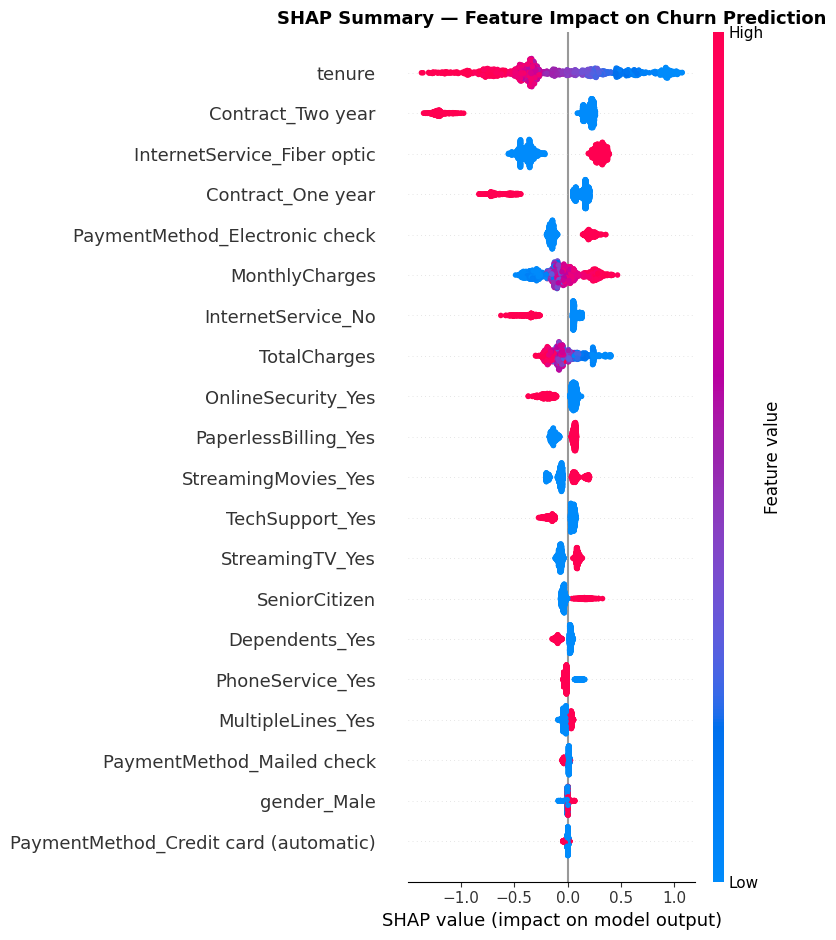

In [21]:
#Plot:1 Beesworm Summary Plot
plt.figure()
shap.summary_plot(shap_values, X_test_df, show=False)
plt.title('SHAP Summary — Feature Impact on Churn Prediction',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\ADMIN\OneDrive\Desktop\Customer Churn Prediction\Visuals\shap_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()

##  Interpretation — SHAP Summary Plot (Beeswarm)

Each dot represents one customer. The position on the x-axis shows whether 
that feature pushed the prediction **toward churn (right)** or 
**away from churn (left)**. Color represents the feature value 
(red = high, blue = low).

**Key Findings:**
- **Tenure** is the most impactful feature — customers with low tenure 
  (blue dots on the right) are significantly more likely to churn. 
  Long-term customers (red dots on the left) tend to stay.
- **Contract_Two year** — customers on a two-year contract (red dots on the left) 
  have a strongly reduced churn probability. This is the clearest retention signal.
- **InternetService_Fiber optic** — fiber optic customers (red dots on the right) 
  are more likely to churn, suggesting possible service quality or pricing issues.
- **PaymentMethod_Electronic check** — using electronic check payment 
  pushes predictions toward churn.
- **Gender, MultipleLines, PhoneService** — appear at the bottom with near-zero 
  SHAP values, confirming they have almost no influence on churn.

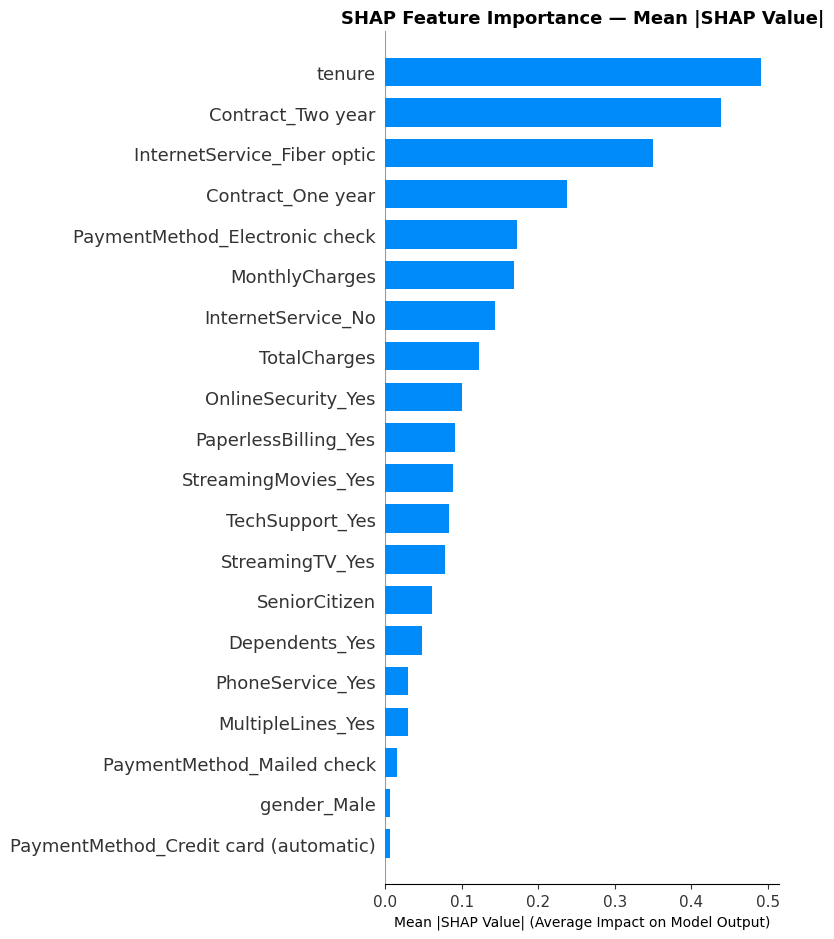

In [22]:
#Plot:2 Bar Plot
plt.figure(figsize=(10, 8))  
shap.summary_plot(
    shap_values,
    X_test_df,
    plot_type='bar',
    show=False,
    max_display=20  # show top 20 features
)
plt.title('SHAP Feature Importance — Mean |SHAP Value|',
          fontsize=13, fontweight='bold')
plt.xlabel('Mean |SHAP Value| (Average Impact on Model Output)', fontsize=10)
plt.tight_layout()
plt.savefig(r'C:\Users\ADMIN\OneDrive\Desktop\Customer Churn Prediction\Visuals\shap_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

##  Interpretation — SHAP Feature Importance (Bar Plot)

This plot shows the **average absolute SHAP value** for each feature — 
i.e. how much each feature moves the prediction on average, regardless of direction.

**Key Findings:**
- **Tenure** ranks #1 with a mean SHAP value of ~0.49 — 
  the single most powerful predictor of churn in this model.
- **Contract_Two year** ranks #2 (~0.44) — 
  contract type is nearly as important as tenure.
- **InternetService_Fiber optic** ranks #3 (~0.35) — 
  internet service type carries significant weight.
- **Contract_One year, Electronic check, MonthlyCharges** 
  form the next tier of important features.
- The bottom 5 features (gender, MultipleLines, PhoneService, 
  Mailed check, Credit card) have minimal impact and could 
  potentially be dropped without affecting model performance.

Customer index:1149
Churn probability:93.9%


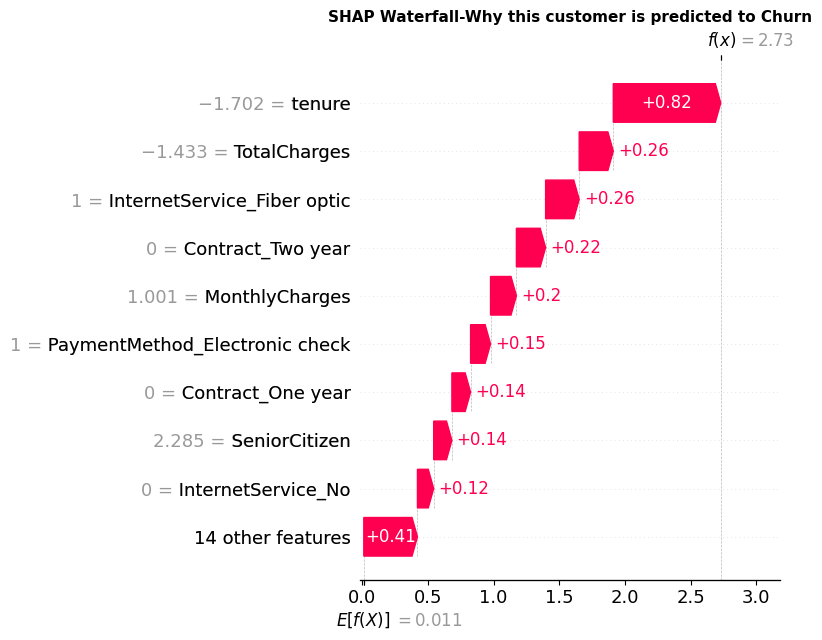

In [24]:
#Plot:3 Waterfall Chart
Y_proba=model.predict_proba(X_test)[:,1]
churn_idx=Y_proba.argmax()

print(f'Customer index:{churn_idx}')
print(f'Churn probability:{Y_proba[churn_idx]:.1%}')

#Explanation of why the Customer is predicted to be churned
explanation=shap.Explanation(
    values=shap_values[churn_idx],
    base_values=explainer.expected_value,
    data=X_test_df.iloc[churn_idx],
    feature_names=feature_names_clean
    
)

#Plottinng
plt.figure()
shap.waterfall_plot(explanation,show=False)
plt.title('SHAP Waterfall-Why this customer is predicted to Churn',fontsize=11,fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\ADMIN\OneDrive\Desktop\Customer Churn Prediction\Visuals\shap_waterfall.png',
            dpi=150, bbox_inches='tight')
plt.show()

##  Interpretation — SHAP Waterfall Plot (Single Customer)

This plot explains **why the model predicted this specific customer will churn**.
The baseline prediction E[f(x)] = 0.011 represents the average prediction 
across all customers. Each bar shows how much a feature pushed the 
final prediction up or down from that baseline.

**This customer's profile:**
- `tenure = -1.702` (very new customer) → **+0.82** strongest push toward churn
- `InternetService = Fiber optic` → **+0.26** increases churn risk
- `TotalCharges = -1.433` (low total charges, confirms new customer) → **+0.26**
- `Contract_Two year = 0` (not on 2-year contract) → **+0.22**
- `MonthlyCharges = 1.001` (high monthly bill) → **+0.20**
- `PaymentMethod = Electronic check` → **+0.15**

**Final prediction: f(x) = 2.73** — extremely high churn probability.

**Business Translation:**
> *This customer is newly joined, on fiber optic internet, paying high 
> monthly charges, using electronic check, and not committed to a 
> long-term contract — a textbook high-risk churn profile. 
> Immediate retention action is recommended.*